# Cholesky Decomposition

For the Cholesky decomposition

$$
A=LL^T,
$$

the diagonal elements of $L$ are computed by

$$
l_{jj}
=
\sqrt{
a_{jj}
-
\sum_{k=1}^{j-1} l_{jk}^2
},
\qquad j=1,\ldots,n.
$$

The elements below the diagonal are computed by

$$
l_{ij}
=
\frac{
a_{ij}
-
\sum_{k=1}^{j-1} l_{ik}l_{jk}
}{
l_{jj}
},
\qquad i=j+1,\ldots,n.
$$

The elements above the diagonal are zero:

$$
l_{ij}=0,
\qquad i<j.
$$


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu
import time
np.set_printoptions(suppress=True, precision=8)
rng = np.random.default_rng(7)

## 1. From-Scratch Implementation

In [35]:
def cholesky_decomposition(A, symmetry_tol=1e-12):
    """Return the lower-triangular Cholesky factor of an SPD matrix."""
    A  = np.asarray(A)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("A must be a square matrix.")

    if not np.all(np.isfinite(A)):
        raise ValueError("A must contain only finite values.")

    if not np.allclose(A, A.T, atol=symmetry_tol, rtol=symmetry_tol):
        raise ValueError("A must be symmetric.")
    
    n = A.shape[0]
    L = np.zeros_like(A)

    for j in range (n):
        diag = A[j, j] - L[j, :j] @ L[j, :j]
        if np.abs(diag) < symmetry_tol:
            raise ValueError("A must be positive definite.")
        L[j, j] = np.sqrt(diag)
        
        if j < n - 1:
            L[j + 1:, j] = (A[j + 1:, j] - L[j + 1:, :j] @ L[j, :j]) / L[j, j]
    return L


## 2. Verification

In [36]:
rng = np.random.default_rng(7)

M = rng.normal(size=(5, 5))
A = M.T @ M + 0.5 * np.eye(5)

In [37]:
L = cholesky_decomposition(A)

assert np.allclose(L, np.tril(L))
assert np.all(np.diag(L) > 0)
assert np.allclose(A, L @ L.T)

residual = (
    np.linalg.norm(A - L @ L.T, ord=np.inf)
    / np.linalg.norm(A, ord=np.inf)
)

print(L)
print(L.T)
print(f"normalized residual = {residual:.3e}")

[[ 2.36616655  0.          0.          0.          0.        ]
 [-0.16318231  1.59868277  0.          0.          0.        ]
 [ 0.31206517  0.62573489  1.92596588  0.          0.        ]
 [-0.75662737  1.08881879 -0.22460458  2.06904943  0.        ]
 [-0.24719729  0.9211573  -0.42463391  0.9407126   0.8973056 ]]
[[ 2.36616655 -0.16318231  0.31206517 -0.75662737 -0.24719729]
 [ 0.          1.59868277  0.62573489  1.08881879  0.9211573 ]
 [ 0.          0.          1.92596588 -0.22460458 -0.42463391]
 [ 0.          0.          0.          2.06904943  0.9407126 ]
 [ 0.          0.          0.          0.          0.8973056 ]]
normalized residual = 6.865e-17


## 3. Solving $Ax=b$ with the Cholesky Factors

Given $A=LL^T$, the linear system becomes

$$L(L^Tx)=b.$$

Introduce the intermediate vector $y=L^Tx$. The solution is obtained in two triangular solves:

1. solve $Ly=b$ by forward substitution;
2. solve $L^Tx=y$ by backward substitution.

In [38]:
# Triangular solvers shared with the LU factorization workflow.
def forward_substitution(L, b):
    """Solve a lower-triangular system Ly = b."""
    b = np.asarray(b, dtype=float)
    n = L.shape[0]
    y = np.empty_like(b, dtype=float)
    for i in range(n):
        y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i, i]
    return y

def backward_substitution(U, y):
    """Solve an upper-triangular system Ux = y."""
    y = np.asarray(y, dtype=float)
    n = U.shape[0]
    x = np.empty_like(y, dtype=float)
    for i in range(n - 1, -1, -1):
        if U[i, i] == 0:
            raise np.linalg.LinAlgError("Singular upper-triangular system.")
        x[i] = (y[i] - U[i, i + 1 :] @ x[i + 1 :]) / U[i, i]
    return x

def cholesky_solve(L, b):
    """Solve LL.T x = b from a precomputed Cholesky factor."""
    y = forward_substitution(L, b)
    x = backward_substitution(L.T, y)
    return x



In [39]:
x_true = rng.normal(size=A.shape[0])
b = A @ x_true

L = cholesky_decomposition(A)
x_computed = cholesky_solve(L, b)

forward_error = (
    np.linalg.norm(x_computed - x_true, ord=np.inf)
    / np.linalg.norm(x_true, ord=np.inf)
)

backward_error = (
    np.linalg.norm(b - A @ x_computed, ord=np.inf)
    / (
        np.linalg.norm(A, ord=np.inf)
        * np.linalg.norm(x_computed, ord=np.inf)
        + np.linalg.norm(b, ord=np.inf)
    )
)

print(f"Computed solution = {x_computed}")
print(f"Relative forward error  = {forward_error:.3e}")
print(f"Relative backward error = {backward_error:.3e}")

x_computed = [-0.18693094 -2.51675971 -0.5386929  -0.04850095  0.11330899]
forward error  = 1.875e-16
backward error = 2.246e-17


## 4. Why Cholesky Factorization Does Not Require Pivoting

If $A$ is symmetric positive definite, then all of its leading principal minors are positive:

$$
\det\left(A_{1:k,\,1:k}\right)>0,
\qquad k=1,\ldots,n.
$$

During Cholesky factorization, each diagonal element of $L$ satisfies

$$
l_{kk}^2
=
a_{kk}
-
\sum_{j=1}^{k-1}l_{kj}^2
>0.
$$

Therefore,

$$
l_{kk}
=
\sqrt{
a_{kk}
-
\sum_{j=1}^{k-1}l_{kj}^2
}
$$

is always real, positive, and nonzero.

Furthermore, every Schur complement generated during the factorization remains symmetric positive definite. Consequently, Cholesky factorization does not encounter zero or negative pivots and does not require row exchanges.

This is why a symmetric positive-definite matrix can be factorized directly as

$$
A=LL^T
$$

without pivoting.




## 5. Runtime Comparison with LU Factorization

For symmetric positive-definite matrices, Cholesky factorization uses the matrix structure directly and requires approximately half the arithmetic work of a general LU factorization. The following experiment compares the median runtime of the two from-scratch implementations.

In [40]:
def lu_partial_pivot(A):
    """Compute PA = LU using Gaussian elimination with partial pivoting."""
    A_demo = A.copy().astype(float)
    n = A.shape[0]
    L = np.eye(n)
    P = np.eye(n)
    U = np.zeros_like(A_demo)

    for i in range (n):
        # Select the largest-magnitude entry in the active column as the pivot.
        max_idx = i + np.argmax(np.abs(A_demo[i:, i]))
        if max_idx != i:
            A_demo[[i, max_idx], :] = A_demo[[max_idx, i], :]
            P[[i, max_idx], :] = P[[max_idx, i], :]
            if i > 0:
                L[[i, max_idx], :i] = L[[max_idx, i], :i]

        U[i,i:]  = A_demo[i,i:]

        if i < n-1:
            L[i+1:,i] = A_demo[i+1:,i]/A_demo[i,i]
            l_1 = L[i+1:,i]
            u_1T = U[i,i+1:]

            A_demo[i+1:,i+1:] = A_demo[i+1:,i+1:] - np.outer(l_1,u_1T)
    return L,U,P

In [41]:
def median_runtime(function, A, repeats=5):
    """Return the median execution time over repeated factorizations."""
    samples = []
    for _ in range(repeats):
        start = time.perf_counter()
        function(A)
        samples.append(time.perf_counter() - start)
    return np.median(samples)

sizes = np.array([25, 50, 100, 200, 350])
LU_times = []
Cholesky_times = []

for n in sizes:
    M_n = rng.normal(size=(n, n))
    A_n = M_n.T @ M_n + 0.5 * np.eye(n)
    LU_times.append(median_runtime(lu_partial_pivot, A_n))
    Cholesky_times.append(median_runtime(cholesky_decomposition, A_n))

lu_times = np.asarray(LU_times)
cholesky_times = np.asarray(Cholesky_times)

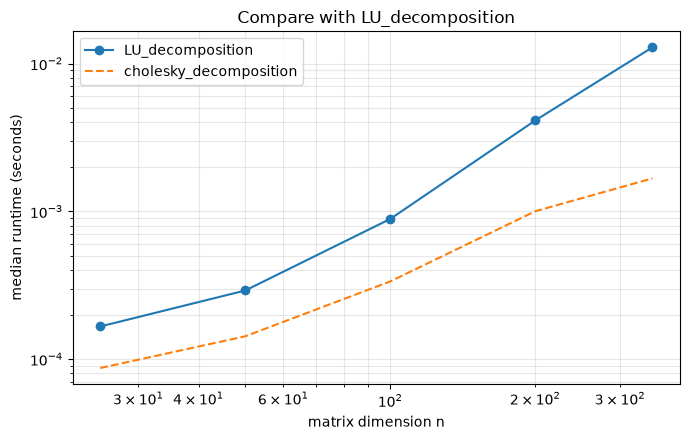

In [42]:
plt.figure(figsize=(7, 4.5))
plt.loglog(sizes, lu_times, "o-", label="LU with partial pivoting")
plt.loglog(sizes, cholesky_times, "s-", label="Cholesky")
plt.xlabel("Matrix dimension n")
plt.ylabel("Median runtime (seconds)")
plt.title("Runtime Comparison on Symmetric Positive-Definite Matrices")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()